# PINN Solution for 2D Heat Equation

2D Heat Equation

\begin{equation}
    \begin{split}
        \underbrace{\frac{\partial u}{\partial t}}_\text{temporal component} \, &= \, \alpha^2 \Bigg( \underbrace{\frac{\partial^2 u}{\partial x^2} 
                                                                                                                + \frac{\partial^2 u}{\partial y^2}}
                                                                                                                   _\text{spacial components} \Bigg) \\[2em]
    \end{split}
\end{equation}

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt

## Define the Neural Network

In [2]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN,self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3,64),                # Input layer with 3 inputs, connected to the first layer (64 nodes)
            nn.Tanh(),                      # Activation function
            nn.Linear(64,64),               # Connection 1st hidden layer to 2nd hidden layer where the 2nd layer has 64 nodes as well
            nn.Tanh(),
            nn.Linear(64,1)                 # 64 nodes from the 2nd layer mapping to the output node 
        )
        
    def forward(self,x):
        return self.net(x)

## Initial Conditions and Boundary Conditions

In [3]:
11.9//2

5.0

In [4]:
# Set initial condition (IC), Note: t is always 0 in the IC and can hence be ommitted here 
def intial_condition(x, y):
    return torch.sin(torch.pi*x) * torch.sin(torch.pi*y)


# Set boundary condition (BC)
def boundary_condition(x, y, t, custom_value):
    return torch.full_like(x, custom_value)


# Generate training data for inside the domains where points are in [0, 1]
def generate_training_data(num_points):
    x = torch.rand(num_points, 1, requires_grad=True)               # generate random points for x from interval [0, 1]
    y = torch.rand(num_points, 1, requires_grad=True)
    t = torch.rand(num_points, 1, requires_grad=True)
    
    return x, y, t


# Generate boundary points for x and y
def generate_boundary_points(num_points):
    x_boundary = torch.tensor([0.0, 1.0]).repeat(num_points//2)     # generate a tensor filled alternating with 0 and 1; //2 because each iterations adds a tuple [0, 1] where //2 indicates floor devision: 11.9//2=5
    y_boundary = torch.rand(num_points)                             # generate random points on y domain
    
    # Switch generated points, i.e. y points only 0 or 1 whereas x points are now randomly distributed over the whole domain
    if torch.rand(1) > 0.5:
        x_boundary, y_boundary = y_boundary, x_boundary             # Note the switch in assignment
        
    # Reshape such that each of the tensor's entries is encapsulated in an own tensor 
    return x_boundary.view(-1, 1), y_boundary.view(-1, 1)


# Generate random points for t as well as boundary points for x and y
def generate_boundary_training_data(num_points):
    x_boundary, y_boundary = generate_boundary_points(num_points)
    t = torch.rand(num_points, 1, requires_grad=True)
    
    return x_boundary, y_boundary, t


# Calulate the heat equation residual or PDE loss
def pde(x, y, t, model):
    input_data = torch.cat([x, y, t], dim=1)                # concatenate the tensors of x, y and t
    u = model(input_data)

    # Get first order derivatives w.r.t x, y and t
    u_x, u_y = torch.autograd.grad(u, [x, y], grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True) 
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True, retain_graph=True)[0]           # [0] to extract the value from the tensor
    
    # Get second order derivatives w.r.t x and y
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True, retain_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True, retain_graph=True)[0]
    
    # Calculate residual
    heat_eq_residual = 1*u_xx + 1*u_yy - u_t                # see Eq. (1) above. Note: There can be individual alphas for x and y but for simplicity we use alpha_x = alpha_y = 1

    return heat_eq_residual

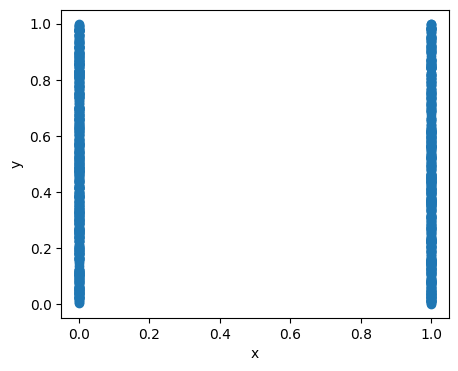

In [51]:
# For some intuition for generate_boundary_training_data(): One of the variables x and y will always be assuming values of 0 and 1, ... 
# ... while the other variable is randomly distributed over the interval [0, 1]

x_boundary, y_boundary, t = generate_boundary_training_data(1000)

plt.figure(figsize = (5,4))
plt.scatter(x_boundary, y_boundary)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [9]:
def train_PINN(model, num_iterations, num_points):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)                 # use Adam optimizer
    
    for iteration in range(num_iterations):
        optimizer.zero_grad()
        
        # Generate training points
        x, y, t = generate_training_data(num_points)                    # generate points in the domains x, y, t
        x_b, y_b, t_b = generate_boundary_training_data(num_points)     # generate boundary points
        
        t_initial = torch.zeros_like(t)
        u_initial = intial_condition(x, y)                               # Derive initial condition for u given training data x and y
        
        custom_value = 0
        u_boundary_x = boundary_condition(x_b, y_b, t_b, custom_value)
        u_boundary_y = boundary_condition(y_b, x_b, t_b, custom_value)
        
        residual = pde(x, y, t, model)
        
        # Calculate total loss = IC loss + BC loss + PDE loss
        loss = nn.MSELoss()(u_initial, model(torch.cat([x, y, t_initial], dim=1))) + \
               nn.MSELoss()(u_boundary_x, model(torch.cat([x_b, y_b, t_b], dim=1))) + \
               nn.MSELoss()(u_boundary_y, model(torch.cat([y_b, x_b, t_b], dim=1))) + \
               nn.MSELoss()(residual, torch.zeros_like(residual))
                
        loss.backward()
        optimizer.step()
        
        if iteration % 100==0:
            print("Iteration:", iteration, ", Loss:", loss.item())

In [11]:
# Train the model
model = PINN()
num_iterations = 10000
num_points = 1000
train_PINN(model, num_iterations, num_points)

Itration: 0 , Loss: 0.21902967989444733
Itration: 100 , Loss: 0.13333405554294586
Itration: 200 , Loss: 0.11814987659454346
Itration: 300 , Loss: 0.10385431349277496
Itration: 400 , Loss: 0.09427490085363388
Itration: 500 , Loss: 0.08310291916131973
Itration: 600 , Loss: 0.07637656480073929
Itration: 700 , Loss: 0.06619255989789963
Itration: 800 , Loss: 0.06455586105585098
Itration: 900 , Loss: 0.060418229550123215
Itration: 1000 , Loss: 0.05506549030542374
Itration: 1100 , Loss: 0.05461028218269348
Itration: 1200 , Loss: 0.04774776101112366
Itration: 1300 , Loss: 0.0457092821598053
Itration: 1400 , Loss: 0.03894394636154175
Itration: 1500 , Loss: 0.036569926887750626
Itration: 1600 , Loss: 0.031885456293821335
Itration: 1700 , Loss: 0.032227158546447754
Itration: 1800 , Loss: 0.028021251782774925
Itration: 1900 , Loss: 0.024825258180499077
Itration: 2000 , Loss: 0.02745754085481167
Itration: 2100 , Loss: 0.023580338805913925
Itration: 2200 , Loss: 0.023662986233830452
Itration: 2300 ,

## Result Evaluation

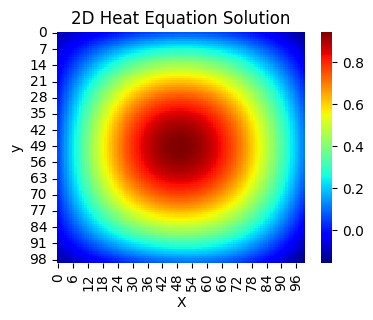

In [34]:
# Plot results for t=0, not that the color bar values of the heatmap change for different t

with torch.no_grad():
    x_vals = torch.linspace(0, 1, 100)
    y_vals = torch.linspace(0, 1, 100)
    X, Y = torch.meshgrid(x_vals, y_vals)
    t_val = torch.ones_like(X) * 0          # specify the time t [0, 1]
    
    input_data = torch.stack([X.flatten(), Y.flatten(), t_val.flatten()], dim=1)
    solution = model(input_data).reshape(X.shape, Y.shape)
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(solution, cmap="jet")                               # Note: Value range of the heatmap's color bar changes in t; better for spacial comparison for a given point in time
    #sns.heatmap(solution, cmap="jet", vmin=0, vmax=1)              # draw heatmap with constant color bar values, for better comparison of temperature decay over time
    plt.title("2D Heat Equation Solution")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.show()

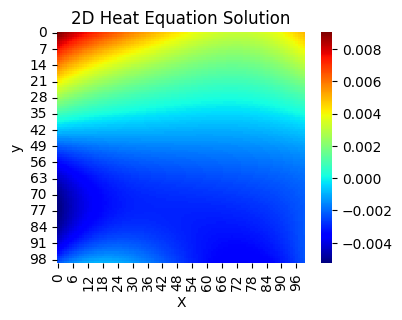

In [35]:
# Plot results for t=1

with torch.no_grad():
    x_vals = torch.linspace(0, 1, 100)
    y_vals = torch.linspace(0, 1, 100)
    X, Y = torch.meshgrid(x_vals, y_vals)
    t_val = torch.ones_like(X) * 1          # specify the time t [0, 1]
    
    input_data = torch.stack([X.flatten(), Y.flatten(), t_val.flatten()], dim=1)
    solution = model(input_data).reshape(X.shape, Y.shape)
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(solution, cmap="jet")
    plt.title("2D Heat Equation Solution")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.show()